In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, accuracy_score, f1_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import pickle
import joblib
import os
from imblearn.over_sampling import SMOTE

In [2]:
# data = combined, same as the regression model but with the binary label?
df_binary = pd.read_parquet("../0_data/processed_data/data_with_selected_features_LGB_All_scaled_binary.parquet")
df_train = df_binary[df_binary['Type'] == 'Train'].reset_index(drop=True)

df_train

,SMILES,MP,Type,MP_label,RDKit_FpDensityMorgan3,RDKit_TPSA,RDKit_NumRotatableBonds,RDKit_SMR_VSA10,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_MRLOW,...,RDKit_Chi2n,RDKit_SlogP_VSA3,RDKit_fr_Ar_NH,RDKit_EState_VSA4,MACCS_89,RDKit_SMR_VSA9,MACCS_131,RDKit_fr_imidazole,RDKit_Chi0,Binary
0,COc1ccc(cc1)C1(C)CCc2c(-c3c1cc(o3)C)c1c(o2)ccc...,170.00,Train,L,0.521953,-0.457762,-0.257788,-0.426305,1.304807,0.417798,...,1.616871,0.778243,-0.20324,3.472367,2.047792,2.116818,-0.562084,-0.133569,1.335854,0
1,C[C@H]1[C@@H]2CC[C@@H]3[C@](C1=O)(C2)C(=O)OC[C...,296.85,Train,H,0.790196,0.502246,-0.865765,0.037682,2.292861,-0.759300,...,2.229837,2.356382,-0.20324,1.776268,2.047792,-0.586923,-0.562084,-0.133569,0.986054,1
2,Cc1cc(Br)c(cc1Br)C,73.00,Train,L,-1.394071,-1.455709,-0.865765,1.009138,-0.015188,2.162965,...,-0.692189,-0.775518,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,-0.880351,0
3,OC(=O)c1ccc(c(c1)F)C,170.00,Train,L,0.783228,-0.407457,-0.561777,-0.769862,-0.827313,-0.231414,...,-0.725133,-0.775518,-0.20324,-0.399178,-0.488331,-0.586923,-0.562084,-0.133569,-0.746893,0
4,OC(=O)C1CC(=O)c2c1cccc2,116.00,Train,L,1.037805,0.072266,-0.561777,-0.372483,0.412897,-0.623661,...,-0.386943,-0.146109,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,-0.559748,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12049,N#CCC(=O)c1ccc(c(c1)Cl)Cl,116.00,Train,L,0.743032,-0.307410,-0.257788,0.811606,-0.080767,-0.174504,...,-0.677477,-0.775518,-0.20324,-0.906021,-0.488331,0.374209,-0.562084,-0.133569,-0.479979,0
12050,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC,72.00,Train,L,-3.629431,-1.455709,8.253899,-1.180027,-0.407154,0.604831,...,2.908040,-0.775518,-0.20324,-0.906021,-0.488331,-0.586923,-0.562084,-0.133569,2.176568,0
12051,OC(=O)c1ccc2c(c1)CCCC2,155.50,Train,L,0.595646,-0.407457,-0.561777,-0.769862,-0.130908,-0.231340,...,-0.229073,0.910284,-0.20324,0.166894,-0.488331,-0.586923,-0.562084,-0.133569,-0.590538,0
12052,COc1cccc(c1P(c1c(OC)cccc1OC)c1c(OC)cccc1OC)OC,146.00,Train,L,-2.846540,0.100650,1.870134,0.457744,1.279393,0.388075,...,0.932824,-0.775518,-0.20324,0.423557,2.047792,4.876089,-0.562084,-0.133569,1.885874,0


In [10]:
from skopt.space import Real, Integer, Categorical # Added Categorical

def model_development_classifier(data, non_feature_cols, target_col, trials):
    # 1. Setup Features and Target
    X = data.drop(columns=non_feature_cols)
    y = data[target_col].values 

    # 2. Precompute Stratified Folds
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    folds = list(skf.split(X, y))

    # ── Helper: run 10-fold CV ─────────────────────
    def run_cv_f1(model_instance):
        fold_f1_scores = []
        for train_idx, val_idx in folds:
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            model_instance.fit(X_train, y_train)
            preds = model_instance.predict(X_val)
            # Calculate F1 instead of LogLoss
            fold_f1_scores.append(f1_score(y_val, preds, average='weighted'))
            
        return fold_f1_scores

    default_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    base_model    = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

    # In the search_space dictionary inside model_development_classifier:
    search_space  = {
        'num_leaves': Integer(20, 300),
        'max_depth': Integer(3, 12),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'n_estimators': Integer(20, 500),
        'min_child_samples': Integer(10, 50),
        'subsample': Real(0.6, 1.0),
        'colsample_bytree': Real(0.4, 1.0),
        'reg_alpha': Real(1e-5, 10.0, prior='log-uniform'),
        'reg_lambda': Real(1e-5, 10.0, prior='log-uniform'),
        'scale_pos_weight': Categorical([1.0]), # CHANGE THIS: Lock at 1.0 for SMOTE
}

    # ── Trial 0: default hyperparameters ──────────────────────────────
    trial_results = {}
    fold_losses_0 = run_cv_f1(default_model)
    mean_0 = float(np.mean(fold_losses_0))
    std_0  = float(np.std(fold_losses_0))

    # Change 'mean_logloss' to 'mean_score' and 'std_logloss' to 'std_score'
    trial_results[0] = {'mean_score': mean_0, 'std_score': std_0}
    # Fix the print label too (it's F1 now, not LogLoss)
    print(f"Trial  0 (default) | mean F1: {mean_0:.4f} ± {std_0:.4f}")

    # ── Trials 1-N: BayesSearchCV ────────────────────────────────────
    opt = BayesSearchCV(
        base_model,
        search_space,
        n_iter=trials,
        cv=folds,
        scoring='f1_weighted', 
        random_state=42,
        n_jobs=1,
        refit=True,
    )
    opt.fit(X, y)

    for i in range(trials):
        score = opt.cv_results_['mean_test_score'][i]
        std   = opt.cv_results_['std_test_score'][i] # Add this line
        trial_results[i + 1] = {
            'mean_score': score,
            'std_score':  std,    # Add this line
            'params': opt.cv_results_['params'][i]
        }
        print(f"Trial {i+1:>2d} | mean F1: {score:.4f} ± {std:.4f}")

    return trial_results, opt.best_estimator_

In [11]:
from imblearn.under_sampling import EditedNearestNeighbours, RandomUnderSampler
from imblearn.pipeline import Pipeline

# 1. Setup paths and column names
data_prefix = "../0_data/processed_data/"
label = 'MP_label'
output = 'Binary'
model_type = "classifier_undersampling" # This helps label your saved files
model_name = "LGB"
num_trials = 20

# Ensure non_features is a single flat list
non_features = ['SMILES', 'MP', 'Type', label, output]

# Prepare your original X and y from the training data
X = df_train.drop(columns=non_features)
y = df_train[output]


# 1. Define the cleaning step (ENN)
# This removes Low-MP molecules that look too much like High-MP neighbors
cleaner = EditedNearestNeighbours(sampling_strategy='majority')

# 2. Define the balancing step (RandomUnderSampler)
# This shrinks the remaining Low-MP class to exactly match the High-MP count
balancer = RandomUnderSampler(sampling_strategy='majority', random_state=42)

# 3. Create the Pipeline
undersample_pipe = Pipeline([
    ('cleaning', cleaner),
    ('balancing', balancer)
])

# 4. Apply to your training data
X_resampled, y_resampled = undersample_pipe.fit_resample(df_train.drop(columns=non_features), df_train[output])

print(f"Final balanced count: {sum(y_resampled == 1)} High / {sum(y_resampled == 0)} Low")

Final balanced count: 615 High / 615 Low


In [12]:
# 3. Reconstruct the dataframe for your function
df_undersampled = pd.concat([pd.DataFrame(X_resampled), pd.Series(y_resampled, name=output)], axis=1)

# 4. Add metadata columns (SMILES, etc.) 
# Since these are real molecules, we use "undersampled" as the placeholder
for col in non_features:
    if col not in df_undersampled.columns:
        df_undersampled[col] = "undersampled"


# Run the classifier
print(f"--- Running {model_type} Classifier ---")
# IMPORTANT: Since classes are now 50/50, scale_pos_weight is locked to 1.0 internally
results_under, model_under = model_development_classifier(
    data=df_undersampled, 
    non_feature_cols=non_features, 
    target_col=output, 
    trials=20
)

# 7. Save the Trial Results
results_filename = f'model_development_results_{model_name}_{model_type}.pkl'
with open(results_filename, 'wb') as f:
    pickle.dump(results_under, f)

# 8. Save the Best Model
model_filename = f"best_model_{model_name}_{model_type}.joblib"
joblib.dump(model_under, model_filename, compress=3)

print(f"Successfully saved results to {results_filename}")

--- Running classifier_undersampling Classifier ---
Trial  0 (default) | mean F1: 0.8640 ± 0.0412
Trial  1 | mean F1: 0.8665 ± 0.0440
Trial  2 | mean F1: 0.8591 ± 0.0446
Trial  3 | mean F1: 0.8625 ± 0.0358
Trial  4 | mean F1: 0.8501 ± 0.0333
Trial  5 | mean F1: 0.8639 ± 0.0456
Trial  6 | mean F1: 0.8517 ± 0.0383
Trial  7 | mean F1: 0.8608 ± 0.0414
Trial  8 | mean F1: 0.8600 ± 0.0417
Trial  9 | mean F1: 0.8599 ± 0.0408
Trial 10 | mean F1: 0.8689 ± 0.0402
Trial 11 | mean F1: 0.8125 ± 0.0495
Trial 12 | mean F1: 0.8321 ± 0.0474
Trial 13 | mean F1: 0.7745 ± 0.0585
Trial 14 | mean F1: 0.8549 ± 0.0367
Trial 15 | mean F1: 0.8492 ± 0.0401
Trial 16 | mean F1: 0.8281 ± 0.0369
Trial 17 | mean F1: 0.8592 ± 0.0396
Trial 18 | mean F1: 0.8648 ± 0.0468
Trial 19 | mean F1: 0.8362 ± 0.0394
Trial 20 | mean F1: 0.8435 ± 0.0356
Successfully saved results to model_development_results_LGB_classifier_undersampling.pkl


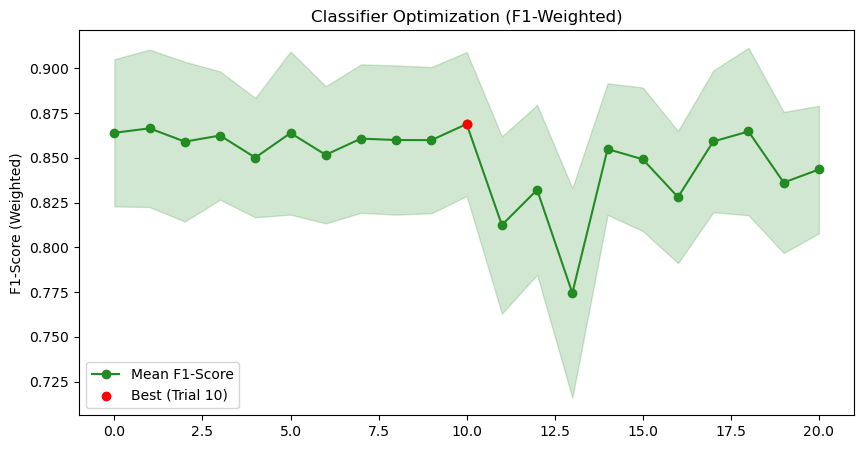

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_classifier_performance(results_dict):
    trials = sorted(results_dict.keys())
    means = [results_dict[t]['mean_score'] for t in trials]
    stds  = [results_dict[t]['std_score']  for t in trials]

    means, stds = np.array(means), np.array(stds)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(trials, means, marker='o', color='forestgreen', label='Mean F1-Score')
    ax.fill_between(trials, means - stds, means + stds, alpha=0.2, color='forestgreen')
    
    best_trial = trials[np.argmax(means)] # argmax because higher F1 is better
    best_f1 = np.max(means)
    
    ax.scatter([best_trial], [best_f1], color='red', zorder=5, label=f'Best (Trial {best_trial})')
    ax.set_ylabel('F1-Score (Weighted)')
    ax.set_title('Classifier Optimization (F1-Weighted)')
    ax.legend()
    plt.show()

plot_classifier_performance(results_under)

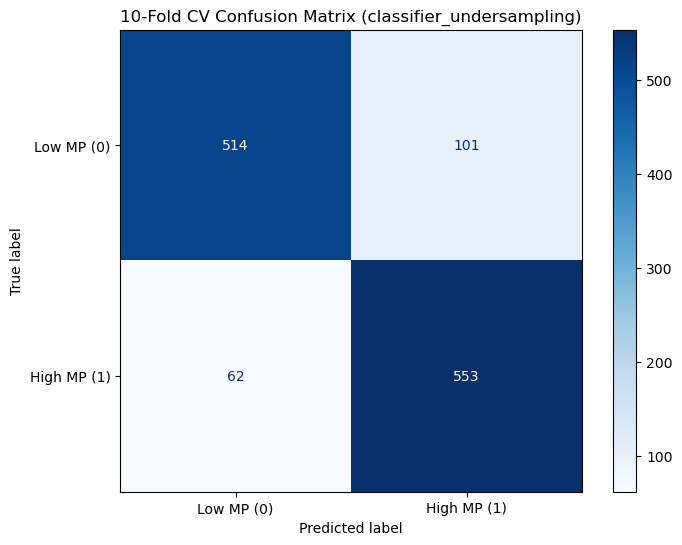

In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate 'Out-of-Fold' predictions for the entire training set
# This uses the best hyperparameters found but ensures each prediction
# is made by a model that didn't see that specific data point during training.
X = df_undersampled.drop(columns=non_features)
y = df_undersampled[output]

y_pred_cv = cross_val_predict(model_under, X, y, cv=10)

# 2. Compute the matrix
cm = confusion_matrix(y, y_pred_cv)

# 3. Plot the matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low MP (0)', 'High MP (1)'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'10-Fold CV Confusion Matrix ({model_type})')
plt.show()

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Calculate individual metrics
accuracy  = accuracy_score(y, y_pred_cv)
precision = precision_score(y, y_pred_cv) # Focuses on 'High MP' (Class 1)
recall    = recall_score(y, y_pred_cv)    # Focuses on 'High MP' (Class 1)
f1        = f1_score(y, y_pred_cv)        # Harmonic mean of Precision/Recall

# 2. Print a clean summary
print(f"--- Performance Metrics: {model_type} Strategy ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (When model says 'High', how often is it right?)")
print(f"Recall:    {recall:.4f} (How many 'High' compounds did we catch?)")
print(f"F1-Score:  {f1:.4f}")
print("-" * 45)

# 3. Print the full report for both classes
print("Full Classification Report:")
print(classification_report(y, y_pred_cv, target_names=['Low MP', 'High MP']))

--- Performance Metrics: classifier_undersampling Strategy ---
Accuracy:  0.8675
Precision: 0.8456 (When model says 'High', how often is it right?)
Recall:    0.8992 (How many 'High' compounds did we catch?)
F1-Score:  0.8716
---------------------------------------------
Full Classification Report:
              precision    recall  f1-score   support

      Low MP       0.89      0.84      0.86       615
     High MP       0.85      0.90      0.87       615

    accuracy                           0.87      1230
   macro avg       0.87      0.87      0.87      1230
weighted avg       0.87      0.87      0.87      1230



TEST SET EVALUATION

In [17]:
# Binary classifier
# data = combined, same as the regression model but with the binary label?
df = pd.read_parquet("../0_data/processed_data/data_with_selected_features_LGB_All_scaled_binary.parquet")
df_test = df[df['Type'] == 'Test'].reset_index(drop=True)

df_test

,SMILES,MP,Type,MP_label,RDKit_FpDensityMorgan3,RDKit_TPSA,RDKit_NumRotatableBonds,RDKit_SMR_VSA10,RDKit_BCUT2D_LOGPHI,RDKit_BCUT2D_MRLOW,...,RDKit_Chi2n,RDKit_SlogP_VSA3,RDKit_fr_Ar_NH,RDKit_EState_VSA4,MACCS_89,RDKit_SMR_VSA9,MACCS_131,RDKit_fr_imidazole,RDKit_Chi0,Binary
0,C/C(=C\C(=N/Nc1ccc(cc1[N+](=O)[O-])[N+](=O)[O-...,115.0,Test,L,0.273579,1.654480,1.262156,0.802312,0.225087,-1.105193,...,0.667614,-0.775518,-0.20324,0.531278,-0.488331,-0.586923,-0.562084,-0.133569,1.401025,0
1,COC(=O)C(=C(SCc1ccccc1)SCc1ccccc1)C#N,104.0,Test,L,-0.835231,-0.048016,1.262156,0.846509,0.612333,-0.617962,...,0.304196,1.986153,-0.20324,0.023628,-0.488331,0.374209,-0.562084,-0.133569,0.908283,0
2,CC(=O)c1ccc(c(c1)F)O,128.0,Test,L,0.783228,-0.407457,-0.561777,-0.782647,-0.440110,-0.171672,...,-0.744034,-0.775518,-0.20324,0.107665,-0.488331,0.323579,-0.562084,-0.133569,-0.746893,0
3,NC(=O)C1=C(CCCC1)CCc1ccccc1,113.0,Test,L,0.465599,-0.244739,0.350190,-0.774131,0.168145,-0.578826,...,0.233292,0.696792,-0.20324,2.241899,-0.488331,-0.586923,-0.562084,-0.133569,-0.056709,0
4,OCCOc1ccccc1,12.0,Test,L,0.521953,-0.627787,0.046201,-1.180027,-0.902406,0.016888,...,-0.880423,-0.775518,-0.20324,-0.425651,-0.488331,0.323579,-0.562084,-0.133569,-0.972721,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5161,CN(CCNCc1cc(ccc1O)[N+](=O)[O-])C,158.5,Test,L,1.029135,0.754332,0.958167,-0.789234,-0.107671,-1.088784,...,-0.004857,0.083653,-0.20324,0.187604,-0.488331,0.323579,1.779092,-0.133569,0.084641,0
5162,C[Si](C#Cc1ccc(cc1)C#C[Si](C)(C)C)(C)C,120.0,Test,L,-2.139191,-1.455709,-0.865765,-0.070479,-0.999456,2.659783,...,1.017151,-0.775518,-0.20324,0.023628,-0.488331,3.044038,-0.562084,-0.133569,0.268670,0
5163,Brc1ccc(c(c1)C(F)(F)F)[N+](=O)[O-],34.0,Test,L,0.248235,-0.243334,-0.561777,0.305349,0.655692,-1.094674,...,-0.665594,0.035283,-0.20324,-0.399178,-0.488331,-0.586923,-0.562084,-0.133569,-0.275050,0
5164,OC(=O)C(C(=O)O)Cc1ccccc1,121.0,Test,L,-0.436059,0.640795,0.350190,-0.359698,-0.795887,-0.653368,...,-0.462402,1.326200,-0.20324,-0.906021,2.047792,-0.586923,1.779092,-0.133569,-0.346521,0


In [18]:
# 1. Prepare the test features (X_test) and actual labels (y_test)
X_test = df_test.drop(columns=non_features)
y_test = df_test[output]

# 2. Use the single "Best Model" to make predictions
y_pred_test = model_under.predict(X_test)

# 3. Get the probabilities (useful for confidence analysis)
y_prob_test = model_under.predict_proba(X_test)[:, 1]

print("Predictions completed on the test set.")

Predictions completed on the test set.


--- Performance Metrics: classifier_undersampling Strategy ---
Accuracy:  0.8357
Precision: 0.2199 (When model says 'High', how often is it right?)
Recall:    0.8745 (How many 'High' compounds did we catch?)
F1-Score:  0.3514
---------------------------------------------
--- Final Test Results: classifier_undersampling Strategy ---
              precision    recall  f1-score   support

      Low MP       0.99      0.83      0.91      4903
     High MP       0.22      0.87      0.35       263

    accuracy                           0.84      5166
   macro avg       0.61      0.85      0.63      5166
weighted avg       0.95      0.84      0.88      5166



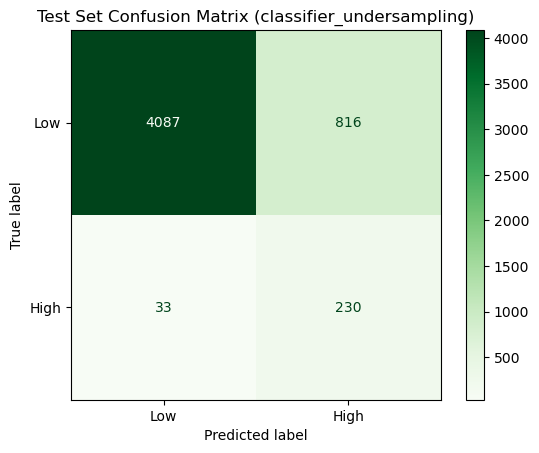

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Calculate individual metrics
accuracy  = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test) # Focuses on 'High MP' (Class 1)
recall    = recall_score(y_test, y_pred_test)    # Focuses on 'High MP' (Class 1)
f1        = f1_score(y_test, y_pred_test)        # Harmonic mean of Precision/Recall

# 2. Print a clean summary
print(f"--- Performance Metrics: {model_type} Strategy ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (When model says 'High', how often is it right?)")
print(f"Recall:    {recall:.4f} (How many 'High' compounds did we catch?)")
print(f"F1-Score:  {f1:.4f}")
print("-" * 45)

# 1. The Text Report
print(f"--- Final Test Results: {model_type} Strategy ---")
print(classification_report(y_test, y_pred_test, target_names=['Low MP', 'High MP']))

# 2. The Confusion Matrix
cm_test = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Low', 'High'])
disp.plot(cmap='Greens')
plt.title(f'Test Set Confusion Matrix ({model_type})')
plt.show()

COMPARISON


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the metrics you want to compare
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Placeholder data: Replace these values with your actual results
# Format: [Weighted, Undersampled, Oversampled]
train_results = {
    'Accuracy':  [0.9559, 0.9527, 0.8675, 0.9809],
    'Precision': [0.6567, 0.5427, 0.8456, 0.9875],
    'Recall':    [0.2862, 0.4650, 0.8992, 0.9740],
    'F1-Score':  [0.3986, 0.5009, 0.8716, 0.9807]
}

test_results = {
    'Accuracy':  [0.9551, 0.9510, 0.8357, 0.9537],
    'Precision': [0.6183, 0.5194, 0.2199, 0.5750],
    'Recall':    [0.3080, 0.5095, 0.8745, 0.3498],
    'F1-Score':  [0.4112, 0.5144, 0.3514, 0.4350]
}

# Transform into a "Long-Form" DataFrame for Seaborn
data_list = []
strategies = ['Unweighted','Weighted', 'Undersampled', 'Oversampled']

for i, strategy in enumerate(strategies):
    for metric in metrics:
        # Add Training Row
        data_list.append({
            'Strategy': strategy,
            'Metric': metric,
            'Value': train_results[metric][i],
            'Dataset': 'Training (CV)'
        })
        # Add Test Row
        data_list.append({
            'Strategy': strategy,
            'Metric': metric,
            'Value': test_results[metric][i],
            'Dataset': 'Test Set'
        })

df_plot = pd.DataFrame(data_list)

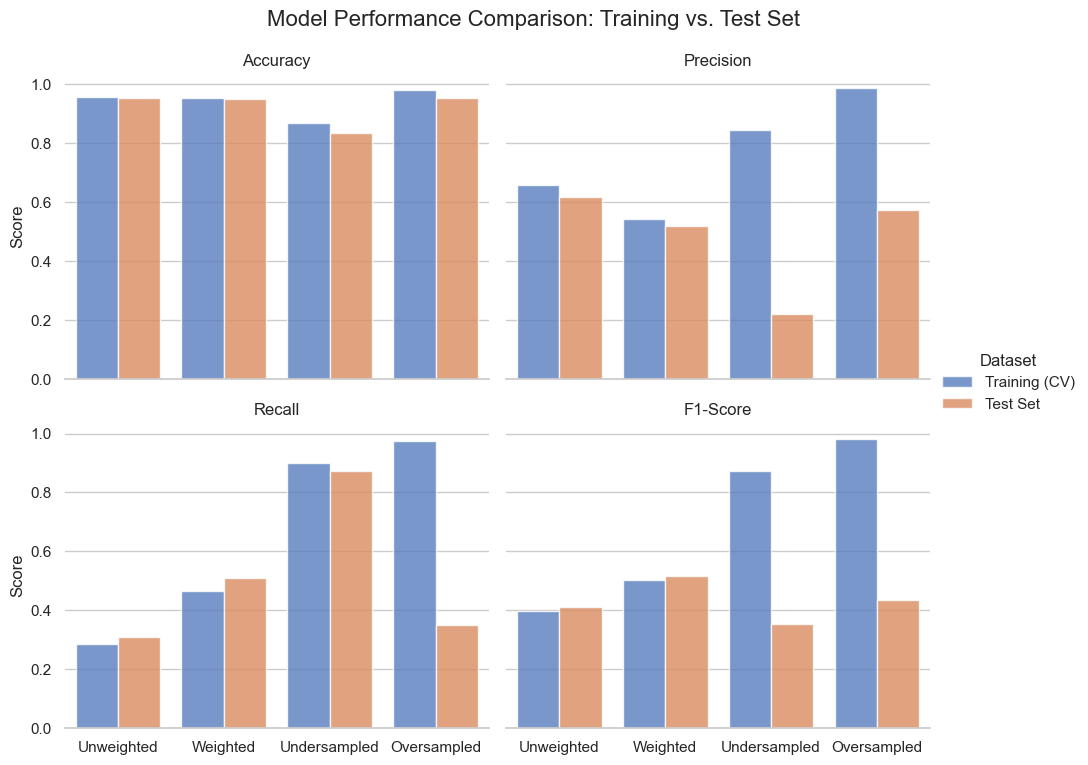

In [26]:
sns.set_theme(style="whitegrid")

# Create a figure with 4 subplots (one for each metric)
g = sns.catplot(
    data=df_plot, kind="bar",
    x="Strategy", y="Value", hue="Dataset",
    col="Metric", col_wrap=2,
    palette="muted", alpha=.8, height=4, aspect=1.2
)

# Refine labels and titles
g.set_axis_labels("", "Score")
g.set_titles("{col_name}")
g.despine(left=True)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Model Performance Comparison: Training vs. Test Set', fontsize=16)

plt.show()